# Contextualizing GWAS hits within celltypes

 Import packages

In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import os
import scanpy as sc
import matplotlib.pyplot as plt

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# helper function to subset cells
def get_n_cells_per_group(adata, group_keys, max_n_cells, min_n_cells=30):
    df = adata.obs.copy()
    l=[]
    for group_key,df1 in df.groupby(group_keys, observed=True):

        if (len(df1)<min_n_cells):
            print(f'Not including group {group_key} because it has only {len(df1)} cells')
        elif (len(df1)<max_n_cells):
            l.append(df1)
        else:
            l.append(df1.sample(max_n_cells,random_state=42))

    df_concat = pd.concat(l,axis=0)
    adata_red = adata[df_concat.index,:]
    
    return adata_red

In [3]:
# function to get gene sets per cell type
def add_ct_gene_sets(
    adata: ad.AnnData,
    ct_key: str,
    n_top_genes: int = 500,
    ensemble_id_col: str = 'gene_ids',
    gene_name_col: str = 'gene_names',
    rgg_key: str = 'rank_genes_groups',
    exclude_hla: bool = True,
    add_geneset_dfs = False
) -> ad.AnnData | None:
    
    """
    Extracts cell type marker gene sets used as input for LD-score regression analysis.
    Leverages output of scanpy.tl.rank_genes_groups.
    ----------
    adata : anndata.AnnData
        AnnData object containing DE results of sc.tl.rank_genes_groups per cell type
    ct_key : str
        Column identifier in adata.obs containing cell type labels
    n_top_genes : int
        Number of top differentially expressed genes per cell type
    ensemble_id_col : str
        Column identifier in adata.obs containing ENSEMBLE IDs
    gene_name_col : str
        Column identifier in adata.obs containing gene names
    rgg_key : str
        Key in adata.uns containing results of sc.tl.rank_genes_groups
    exclude_hla : bool
        If True, genes starting with 'HLA-' are removed.
    add_geneset_dfs : bool, optional
        If True, pd.DataFrames containing the DE results of the n_top_genes 
        are added to adata.uns['ldsc']['gene_set_dfs']
    

    Returns
    -------
    adata object with cell type specific gene sets added in
    adata.varm['ct_gene_sets']. Parameters are stored in adata.uns['ldsc']
    """

    # Ensure rank_genes_groups was run
    if adata.uns[rgg_key]['params']['groupby'] != ct_key:
        raise ValueError(
                f"rank_genes_groups was run on different groupby column. Found {adata.uns[rgg_key]['params']['groupby']}, expected {ct_key}."
            )
        
    # Check presence of gene_id column in adata.var
    if ensemble_id_col not in list(adata.var.columns):
        raise ValueError(
            f"Ensemble IDs not found in adata.var.columns. ensemble_id_col is set to {ensemble_id_col}."
        )

    # Check presence of gene_names column in adata.var
    if gene_name_col not in list(adata.var.columns):
        raise ValueError(
                f"Gene names not found in adata.var.columns. Please add or change column identifier for gene_name_col."
            )
        
    # get cell type specific genes
    de_result_dict = {}

    # Extract DE results and add ensemble ID if needed
    for ct in adata.obs[ct_key].unique():
        
        # extract dea dataframe and store to csv
        dea_df = sc.get.rank_genes_groups_df(adata, group=ct, key=rgg_key,)
        
        # add ensemble ids and gene names consistently if needed
        if dea_df.names[0].startswith('ENS'):
            dea_df[ensemble_id_col] = dea_df.names
            ens_id_to_gene_names = dict(zip(adata.var[ensemble_id_col], adata.var[gene_name_col]))
            dea_df[gene_name_col] = dea_df[ensemble_id_col].map(ens_id_to_gene_names)   
        else:
            # add column with mapped ensemble ids
            dea_df[gene_name_col] = dea_df.names
            gene_name_to_ens_id = dict(zip(adata.var[gene_name_col], adata.var[ensemble_id_col]))
            dea_df[ensemble_id_col] = dea_df[gene_name_col].map(gene_name_to_ens_id)      
        
        # exclude HLA genes, since they have funny LD patterns
        if exclude_hla:
            dea_df = dea_df.loc[~dea_df[gene_name_col].str.startswith("HLA-"), :]
        
        # Sort genes by score
        dea_df_final = dea_df.sort_values(by="scores", ascending=False).iloc[:n_top_genes]

        # TODO: Reduce to only significantly expressed genes
    
        # make sure these do not include genes with negative t statistics
        if (dea_df_final.scores < 0).any():
            raise ValueError(
                f"Note that the top {n_top_genes} of your DEA are partly lower-expressed genes! You might want to check."
            )
        
        # remove spaces from cell type name
        ct_no_spaces = ct.replace(" ", "_")
        ct_no_spaces = ct_no_spaces.replace("/", "_")
        # save result df
        de_result_dict[ct_no_spaces] = dea_df_final

    # Add results to adata.varm
    de_result_dict_bool = {}
    for ct in list(de_result_dict.keys()):
        de_result_dict_bool[ct] = [g in list(de_result_dict[ct][ensemble_id_col]) for g in adata.var[ensemble_id_col]]
    
    adata.varm['ct_gene_sets'] = pd.DataFrame(de_result_dict_bool, index=adata.var_names)
    # Save parameters
    adata.uns['ldsc'] = {'params':{
        'ct_key':ct_key,
        'n_top_genes':n_top_genes,
        'ensemble_id_col':ensemble_id_col,
        'gene_name_col':gene_name_col,
        'rgg_key':rgg_key,
        'exclude_hla':exclude_hla,
        'add_geneset_dfs':add_geneset_dfs
    }}

    if add_geneset_dfs:
        adata.uns['ldsc']['geneset_dfs'] = de_result_dict
    
    return(0)
    

In [4]:
def save_ldsc_gene_sets(
    adata: ad.AnnData,
    save_dir: str,
    ensemble_id_col: str = 'gene_ids',
    gene_name_col: str = 'gene_names',
    ):

    
    # ensure ensemble_id and gene names are in 
    if ensemble_id_col not in list(adata.var.columns):
        raise ValueError(
                f"ensemble_id_col not in adata.var.columns."
            )
    if gene_name_col not in list(adata.var.columns):
        raise ValueError(
                f"gene_name_col not in adata.var.columns."
            )

    # ensure add_ct_gene_sets was run
    #if adata.varm['ct_gene_sets']
        
    # save de genes
    for ct in adata.varm['ct_gene_sets'].columns:
        adata.var['gene_id'][adata.varm['ct_gene_sets'][ct]].to_csv(
            os.path.join(save_dir, f"{ct}.GeneSet"),
            index=False,
            header=False
        )
                
    with open(os.path.join(save_dir, "control.GeneSet"), "w+") as f:
        for gene_name, ens_id in zip(adata.var[gene_name_col], adata.var[ensemble_id_col]):
            # exclude HLA genes
            if not gene_name.startswith("HLA-"):
                f.write(ens_id + "\n")
  

## Load data

In [5]:
# check and set working directory
os.getcwd()

'/Users/kylekimler/gitHub/hca-gut-atlas-downstream/vignettes'

In [6]:
# os.chdir('/ictstr01/groups/ml01/workspace/christopher.lance/hca_gut/')

In [6]:
# Load data
adata = ad.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad')

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Inspect adata file and cell type resolution suitabile for LD-score regression per cell type

To obtain robust DE gene sets per cell type, a resolution should be chosen, which allows at least 50 (or better 100) cells per cell type. For large datasets, we can subsample to 500-1500 cells per celltype to reduce comutational ressources to obtain DE genes per cell type.

In [11]:
adata

AnnData object with n_obs × n_vars = 309637 × 36601
    obs: 'cecilia22_predH', 'cecilia22_predH_prob', 'cecilia22_predH_uncertain', 'cecilia22_predL', 'cecilia22_predL_prob', 'cecilia22_predL_uncertain', 'elmentaite21_pred', 'elmentaite21_pred_prob', 'elmentaite21_pred_uncertain', 'suo22_pred', 'suo22_pred_prob', 'suo22_pred_uncertain', 'n_counts', 'log1p_n_counts', 'n_genes', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'n_counts_raw', 'log1p_n_counts_raw', 'n_genes_raw', 'log1p_n_genes_raw', 'percent_mito_raw', 'n_counts_mito_raw', 'percent_ribo_raw', 'n_counts_ribo_raw', 'percent_hb_raw', 'n_counts_hb_raw', 'percent_top50_raw', 'n_counts_spliced', 'log1p_n_counts_spliced', 'n_genes_spliced', 'log1p_n_genes_spliced', 'percent_mito_spliced', 'n_counts_mito_spliced', 'percent_ribo_spliced', 'n_counts_ribo_spliced', 'percent_hb_spliced', 'n_counts_hb_spliced', 'percent_top50_spliced', 'n_counts_unsplice

In [12]:
# Check how many cells there are per cell type
ct_column = 'level_2_annot'
adata.obs[ct_column].value_counts()

level_2_annot
Absorptive               61142
Conventional_CD4         49481
Mature_B                 39821
B_plasma                 37557
Conventional_CD8         28876
Fibroblast               18116
Unconventional_T/ILC     15947
Secretory                13506
Transit_amplifying       12524
Treg                      9519
Vascular_endothelia       3639
Stem                      3247
Macrophage                2831
Granulocyte               2112
NK                        1902
DC                        1708
Monocyte                  1313
Smooth_muscle             1129
Lymphatic_endothelia       946
Neuron_progenitor          878
Myofibroblast              794
Pericyte                   508
Cycling_T/NK               489
Enteroendocrine            465
Glia                       366
Lymphoid_stromal_cell      362
Microfold                  276
Immature_B                 110
Mesothelium                 49
Cycling_endothelia           9
Erythrocyte                  9
Neuron                   

In [13]:
# Subsample to 1000 cells per cell type
adata_subsamp = get_n_cells_per_group(adata,
                                     group_keys=[ct_column],
                                     max_n_cells=1000,
                                     min_n_cells=30
                                    )

Not including group ('Cycling_endothelia',) because it has only 9 cells
Not including group ('Erythrocyte',) because it has only 9 cells
Not including group ('Neuron',) because it has only 6 cells


In [14]:
adata_subsamp

View of AnnData object with n_obs × n_vars = 23243 × 36601
    obs: 'cecilia22_predH', 'cecilia22_predH_prob', 'cecilia22_predH_uncertain', 'cecilia22_predL', 'cecilia22_predL_prob', 'cecilia22_predL_uncertain', 'elmentaite21_pred', 'elmentaite21_pred_prob', 'elmentaite21_pred_uncertain', 'suo22_pred', 'suo22_pred_prob', 'suo22_pred_uncertain', 'n_counts', 'log1p_n_counts', 'n_genes', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'n_counts_raw', 'log1p_n_counts_raw', 'n_genes_raw', 'log1p_n_genes_raw', 'percent_mito_raw', 'n_counts_mito_raw', 'percent_ribo_raw', 'n_counts_ribo_raw', 'percent_hb_raw', 'n_counts_hb_raw', 'percent_top50_raw', 'n_counts_spliced', 'log1p_n_counts_spliced', 'n_genes_spliced', 'log1p_n_genes_spliced', 'percent_mito_spliced', 'n_counts_mito_spliced', 'percent_ribo_spliced', 'n_counts_ribo_spliced', 'percent_hb_spliced', 'n_counts_hb_spliced', 'percent_top50_spliced', 'n_counts_u

In [15]:
adata_subsamp.obs[ct_column].value_counts()

level_2_annot
Absorptive               1000
B_plasma                 1000
Conventional_CD4         1000
Conventional_CD8         1000
DC                       1000
Granulocyte              1000
Fibroblast               1000
Stem                     1000
Transit_amplifying       1000
Monocyte                 1000
NK                       1000
Mature_B                 1000
Macrophage               1000
Unconventional_T/ILC     1000
Treg                     1000
Vascular_endothelia      1000
Secretory                1000
Smooth_muscle            1000
Lymphatic_endothelia      946
Neuron_progenitor         878
Myofibroblast             794
Pericyte                  508
Cycling_T/NK              489
Enteroendocrine           465
Glia                      366
Lymphoid_stromal_cell     362
Microfold                 276
Immature_B                110
Mesothelium                49
Name: count, dtype: int64

Ensure adata.X is log normalized

In [15]:
# Check whether adata.X contains counts or normalized values
adata_subsamp.X[:100].toarray()[adata_subsamp.X[:100].toarray()>0]

array([  1.,   1.,   3., ...,  12.,   1., 109.], dtype=float32)

We use log-normalized values as input to receive marker genes per cell type. Additionally, for visualization purposes, we obtain highly variable genes and creata a UMAP of our input data.

In [17]:
adata_subsamp.layers['count'] = adata_subsamp.X.copy()

/var/folders/fq/vhljg0vx24qb_fvx7tbd6d_80000gn/T/ipykernel_66623/4013396757.py:1: ImplicitModificationWarning: Setting element `.layers['count']` of view, initializing view as actual.
  adata_subsamp.layers['count'] = adata_subsamp.X.copy()


In [18]:
sc.pp.normalize_total(adata_subsamp, target_sum=1e4)

In [19]:
sc.pp.log1p(adata_subsamp)

In [20]:
sc.pp.highly_variable_genes(adata_subsamp,
                            n_top_genes=2000
                           )

In [21]:
print('Running PCA...')
sc.pp.pca(adata_subsamp)
print('Running Neighbors...')
sc.pp.neighbors(adata_subsamp)
print('Running PCA...')
sc.tl.umap(adata_subsamp)

Running PCA...
Running Neighbors...


/Users/christopher.lance/miniforge3/envs/sc_genetics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running PCA...


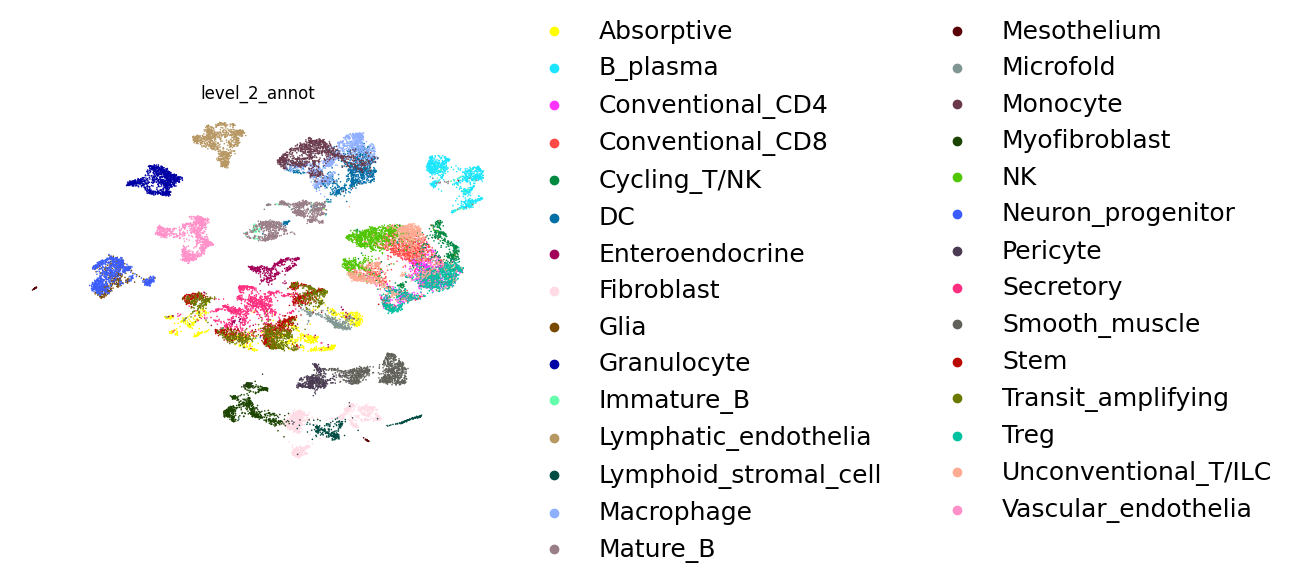

In [22]:
sc.pl.umap(adata_subsamp,
           color=ct_column,
           frameon=False,
           legend_fontsize=18
          )

## Get DE genes per cell type

Next, we run sc.tl.rank_genes_groups to obtain marker genes per cell type.

In [23]:
sc.tl.rank_genes_groups(
    adata_subsamp, groupby=ct_column, use_raw=False, method="wilcoxon"
)

/Users/christopher.lance/miniforge3/envs/sc_genetics/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/christopher.lance/miniforge3/envs/sc_genetics/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/christopher.lance/miniforge3/envs/sc_genetics/lib/python3.10/site-pa

We add ensemble and gene names as columns to adata.var. This ensures that both IDs types are available. ENSEMBLE IDs are needed to run LDSC, while gene names can be used to filter genes such as HLA- genes.

In [25]:
pd.set_option('display.max_columns', None)

In [26]:
adata_subsamp.var.head()

,feature_type,mito,ribo,hb,cc,ig,tcr,n_counts-0,n_counts_raw-0,n_counts_spliced-0,n_counts_unspliced-0,n_cells-0,n_cells_raw-0,n_cells_spliced-0,n_cells_unspliced-0,n_counts-1,n_counts_raw-1,n_counts_spliced-1,n_counts_unspliced-1,n_cells-1,n_cells_raw-1,n_cells_spliced-1,n_cells_unspliced-1,gene_names,highly_variable,means,dispersions,dispersions_norm
gene_ids,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000243485,Gene Expression,False,False,False,False,False,False,34.0,39.0,1.0,60.0,34,39,1,58,1.0,1.0,0.0,8.0,1,1,0,8,MIR1302-2HG,False,1.262573e-05,-1.226008,-3.925726
ENSG00000237613,Gene Expression,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,FAM138A,False,1.000000e-12,NaN,NaN
ENSG00000186092,Gene Expression,False,False,False,False,False,False,22.0,23.0,0.0,2.0,21,22,0,2,14.0,14.0,1.0,1.0,14,14,1,1,OR4F5,True,2.719207e-04,1.843895,1.037049
ENSG00000238009,Gene Expression,False,False,False,False,False,False,1446.0,1489.0,87.0,1593.0,1439,1482,87,1531,259.0,266.0,7.0,221.0,259,266,7,212,AL627309.1,False,2.765366e-03,1.363727,0.260813
ENSG00000239945,Gene Expression,False,False,False,False,False,False,50.0,58.0,0.0,0.0,50,58,0,0,2.0,2.0,0.0,0.0,2,2,0,0,AL627309.3,False,2.509353e-04,1.365378,0.263483


In [27]:
adata_subsamp.var['gene_id'] = adata_subsamp.var_names

In [28]:
adata_subsamp.var.head()

,feature_type,mito,ribo,hb,cc,ig,tcr,n_counts-0,n_counts_raw-0,n_counts_spliced-0,n_counts_unspliced-0,n_cells-0,n_cells_raw-0,n_cells_spliced-0,n_cells_unspliced-0,n_counts-1,n_counts_raw-1,n_counts_spliced-1,n_counts_unspliced-1,n_cells-1,n_cells_raw-1,n_cells_spliced-1,n_cells_unspliced-1,gene_names,highly_variable,means,dispersions,dispersions_norm,gene_id
gene_ids,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000243485,Gene Expression,False,False,False,False,False,False,34.0,39.0,1.0,60.0,34,39,1,58,1.0,1.0,0.0,8.0,1,1,0,8,MIR1302-2HG,False,1.262573e-05,-1.226008,-3.925726,ENSG00000243485
ENSG00000237613,Gene Expression,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,FAM138A,False,1.000000e-12,NaN,NaN,ENSG00000237613
ENSG00000186092,Gene Expression,False,False,False,False,False,False,22.0,23.0,0.0,2.0,21,22,0,2,14.0,14.0,1.0,1.0,14,14,1,1,OR4F5,True,2.719207e-04,1.843895,1.037049,ENSG00000186092
ENSG00000238009,Gene Expression,False,False,False,False,False,False,1446.0,1489.0,87.0,1593.0,1439,1482,87,1531,259.0,266.0,7.0,221.0,259,266,7,212,AL627309.1,False,2.765366e-03,1.363727,0.260813,ENSG00000238009
ENSG00000239945,Gene Expression,False,False,False,False,False,False,50.0,58.0,0.0,0.0,50,58,0,0,2.0,2.0,0.0,0.0,2,2,0,0,AL627309.3,False,2.509353e-04,1.365378,0.263483,ENSG00000239945


Get DE genes and save as files.

In [29]:
adata_subsamp

AnnData object with n_obs × n_vars = 23243 × 36601
    obs: 'cecilia22_predH', 'cecilia22_predH_prob', 'cecilia22_predH_uncertain', 'cecilia22_predL', 'cecilia22_predL_prob', 'cecilia22_predL_uncertain', 'elmentaite21_pred', 'elmentaite21_pred_prob', 'elmentaite21_pred_uncertain', 'suo22_pred', 'suo22_pred_prob', 'suo22_pred_uncertain', 'n_counts', 'log1p_n_counts', 'n_genes', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'n_counts_raw', 'log1p_n_counts_raw', 'n_genes_raw', 'log1p_n_genes_raw', 'percent_mito_raw', 'n_counts_mito_raw', 'percent_ribo_raw', 'n_counts_ribo_raw', 'percent_hb_raw', 'n_counts_hb_raw', 'percent_top50_raw', 'n_counts_spliced', 'log1p_n_counts_spliced', 'n_genes_spliced', 'log1p_n_genes_spliced', 'percent_mito_spliced', 'n_counts_mito_spliced', 'percent_ribo_spliced', 'n_counts_ribo_spliced', 'percent_hb_spliced', 'n_counts_hb_spliced', 'percent_top50_spliced', 'n_counts_unspliced

Now we extract gene sets per cell type and save it in adata.varm

In [30]:
add_ct_gene_sets(
    adata_subsamp,
    ct_key=ct_column,
    n_top_genes=500,
    ensemble_id_col='gene_id',
    gene_name_col='gene_names',
    add_geneset_dfs=True # This saves the DE test results of the selected genes as easy to acces dataframes per cell type to adata.uns.
    )

0

In [31]:
adata_subsamp

AnnData object with n_obs × n_vars = 23243 × 36601
    obs: 'cecilia22_predH', 'cecilia22_predH_prob', 'cecilia22_predH_uncertain', 'cecilia22_predL', 'cecilia22_predL_prob', 'cecilia22_predL_uncertain', 'elmentaite21_pred', 'elmentaite21_pred_prob', 'elmentaite21_pred_uncertain', 'suo22_pred', 'suo22_pred_prob', 'suo22_pred_uncertain', 'n_counts', 'log1p_n_counts', 'n_genes', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'n_counts_raw', 'log1p_n_counts_raw', 'n_genes_raw', 'log1p_n_genes_raw', 'percent_mito_raw', 'n_counts_mito_raw', 'percent_ribo_raw', 'n_counts_ribo_raw', 'percent_hb_raw', 'n_counts_hb_raw', 'percent_top50_raw', 'n_counts_spliced', 'log1p_n_counts_spliced', 'n_genes_spliced', 'log1p_n_genes_spliced', 'percent_mito_spliced', 'n_counts_mito_spliced', 'percent_ribo_spliced', 'n_counts_ribo_spliced', 'percent_hb_spliced', 'n_counts_hb_spliced', 'percent_top50_spliced', 'n_counts_unspliced

In [33]:
save_ldsc_gene_sets(
                    adata_subsamp,
                    save_dir='data/ldsc_out/gene_sets/',
                    ensemble_id_col='gene_id',
                    gene_name_col='gene_names'
                   )

## Load summary statistics and ensure right format

Here, we take a look at the file format of GWAS summary statistics of a phenotype of interst and run the data preparation script of the ldsc package to ensure the right format.

In [7]:
import subprocess

In [8]:
sum_stats = pd.read_csv('data/ldsc_in/GCST90446792.h.tsv.gz',
                        sep='\t'
                       )

In [9]:
# Check the columns
sum_stats.head()

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,variant_id,rsid,FreqSE,MinFreq,MaxFreq,Direction,HetISq,HetChiSq,HetDf,HetPVal,hm_coordinate_conversion,hm_code
0,1,108391,G,A,-0.4717,0.5444,0.0021,0.3862,1_108391_A_G,rs1274919517,0.0,0.0021,0.0021,?????-,0.0,0.0,0,1.0,lo,10
1,1,115637,A,G,0.0883,0.4823,0.0024,0.8548,1_115637_G_A,rs74337086,0.0,0.0024,0.0024,?????+,0.0,0.0,0,1.0,lo,10
2,1,137928,A,G,1.2618,0.8752,0.0008,0.1494,1_137928_G_A,rs1292537993,0.0,0.0008,0.0008,?????+,0.0,0.0,0,1.0,lo,10
3,1,181729,C,CGGTGCT,-0.4731,0.5306,0.0016,0.3726,1_181729_CGGTGCT_C,rs1425927025,0.0,0.0016,0.0016,-?????,0.0,0.0,0,1.0,lo,10
4,1,184280,T,C,-0.4530,0.6109,0.0016,0.4584,1_184280_C_T,rs1264891165,0.0,0.0016,0.0016,?????-,0.0,0.0,0,1.0,lo,10


In [12]:
del sum_stats

**Run for Crohn's disease sumstats**

In [11]:
# Define the name of the environment
env_name = "ldsc"

# Use conda to activate the environment and run the command
command = f"""
source $(conda info --base)/etc/profile.d/conda.sh && \
conda activate {env_name} && \
cd /ictstr01/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
./ldsc/munge_sumstats.py \
    --sumstats data/ldsc_in/GCST90446792.h.tsv.gz \
    --N 367592 \
    --a1 other_allele \
    --a2 effect_allele \
    --chunksize 500000 \
    --out data/ldsc_out/GCST90446792_cd
"""

# Run the command in a subprocess
subprocess.run(command, shell=True, executable="/bin/bash")

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./munge_sumstats.py \
--out data/ldsc_out/GCST90446792_cd \
--chunksize 500000 \
--N 367592.0 \
--a1 other_allele \
--a2 effect_allele \
--sumstats data/ldsc_in/GCST90446792.h.tsv.gz 

Interpreting column names as follows:
effect_allele:	Allele 2, interpreted as non-ref allele for signed sumstat.
p_value:	p-Value
other_allele:	Allele 1, interpreted as ref allele for signed sumstat.
beta:	[linear/logistic] regression coefficient (0 --> no effect; above 0 --> A1 is trait/risk increasing)
rsid:	Variant ID (e.g., rs number)

Reading sumstats from data/ldsc_in/GCST90446792.h.tsv.gz into memory 500000 SNPs at a time.
.............................

CompletedProcess(args='\nsource $(conda info --base)/etc/profile.d/conda.sh && conda activate ldsc && cd /Users/christopher.lance/PhD/projects/hca_gut/hca-gut-atlas-downstream/ && ./ldsc/munge_sumstats.py     --sumstats data/ldsc_in/GCST90446792.h.tsv.gz     --N 367592     --a1 other_allele     --a2 effect_allele     --chunksize 500000     --out data/ldsc_out/GCST90446792_cd\n', returncode=0)

**Run for UC sumstats**

In [13]:
# Define the name of the environment
env_name = "ldsc"

# Use conda to activate the environment and run the command
command = f"""
source $(conda info --base)/etc/profile.d/conda.sh && \
conda activate {env_name} && \
cd /ictstr01/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
./ldsc/munge_sumstats.py \
    --sumstats data/ldsc_in/GCST90446794.h.tsv.gz \
    --N 367592 \
    --a1 other_allele \
    --a2 effect_allele \
    --chunksize 500000 \
    --out data/ldsc_out/GCST90446794_uc/GCST90446794_uc
"""

# Run the command in a subprocess
subprocess.run(command, shell=True, executable="/bin/bash")

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./munge_sumstats.py \
--out data/ldsc_out/GCST90446794_uc/GCST90446794_uc \
--chunksize 500000 \
--N 367592.0 \
--a1 other_allele \
--a2 effect_allele \
--sumstats data/ldsc_in/GCST90446794.h.tsv.gz 

Interpreting column names as follows:
effect_allele:	Allele 2, interpreted as non-ref allele for signed sumstat.
p_value:	p-Value
other_allele:	Allele 1, interpreted as ref allele for signed sumstat.
beta:	[linear/logistic] regression coefficient (0 --> no effect; above 0 --> A1 is trait/risk increasing)
rsid:	Variant ID (e.g., rs number)

Reading sumstats from data/ldsc_in/GCST90446794.h.tsv.gz into memory 500000 SNPs at a time.
.............

CompletedProcess(args='\nsource $(conda info --base)/etc/profile.d/conda.sh && conda activate ldsc && cd /Users/christopher.lance/PhD/projects/hca_gut/hca-gut-atlas-downstream/ && ./ldsc/munge_sumstats.py     --sumstats data/ldsc_in/GCST90446794.h.tsv.gz     --N 367592     --a1 other_allele     --a2 effect_allele     --chunksize 500000     --out data/ldsc_out/GCST90446794_uc/GCST90446794_uc\n', returncode=0)

## Run ldsc per chromosome and celltype

In addition to the input files generated below, other reference files can be found here: https://zenodo.org/records/10515792

In [16]:
import gzip

### Prep gene coordinate file

Another input needed for LDSC is a coordinate file of all genes, here we create one based on a gtf file of a recent genome version.

In [17]:
# Function to parse GTF (gzip) and generate the coordinate file
def parse_gtf(gtf_file):
    gene_data = []

    # Open the gzip file in read mode
    with gzip.open(gtf_file, 'rt') as f:  # 'rt' for reading text mode
        for line in f:
            # Skip header lines
            if line.startswith('#'):
                continue

            # Split the line into fields
            fields = line.strip().split('\t')
            
            # We're only interested in 'gene' feature type lines
            feature_type = fields[2]
            if feature_type != 'gene':
                continue

            # Extract relevant fields
            chrom = fields[0].replace('chr', '')  # Remove 'chr' prefix
            start = int(fields[3])
            end = int(fields[4])
            strand = fields[6]
            attributes = fields[8]

            # Parse attributes to extract gene_id (Ensembl ID)
            attr_dict = {}
            for attribute in attributes.split(';'):
                if attribute.strip():
                    key, value = attribute.strip().split(' ')
                    attr_dict[key] = value.strip('"')

            # Use Ensembl gene_id, and remove version number
            gene_id = attr_dict.get('gene_id').split('.')[0]

            # Determine TSS and TES - TODO: double check if strand is an issue
            tss = start
            tes = end

            # Append to gene_data list
            gene_data.append([gene_id, chrom, tss, tes])

    # Convert to DataFrame
    df = pd.DataFrame(gene_data, columns=['GENE', 'CHR', 'START', 'END'])

    return df

In [118]:
# Example usage
gtf_file = "data/ldsc_in/gencode.v45.annotation.gtf.gz"
df = parse_gtf(gtf_file)

In [119]:
df.head()

,GENE,CHR,START,END
0,ENSG00000290825,1,11869,14409
1,ENSG00000223972,1,12010,13670
2,ENSG00000227232,1,14696,24886
3,ENSG00000278267,1,17369,17436
4,ENSG00000243485,1,29554,31109


In [120]:
# Write the DataFrame to a file
df.to_csv("data/ldsc_in/ENSG_coord.txt",
          sep='\t',
          index=False)

### Create ldsc annot files per cell type and chromosome

In [18]:
# define lists of celltypes and chromosomes
ct_list = list(adata_subsamp.obs[ct_column].unique())
chrom_list = [str(i+1) for i in range(22)]

In [19]:
ct_list = [ct.replace(" ", "_") for ct in ct_list]
ct_list = [ct.replace("/", "_") for ct in ct_list]

In [20]:
# add the control set to the cell type list
ct_list = ct_list+['control']

In [21]:
# Define the name of the conda environment
env_name = "ldsc"

In [25]:
### IDEALLY AS PARALLELIZED JOBS ON CLUSTER

for ct_name  in ct_list:
    for chrom in chrom_list:
        print('Running ', ct_name, 'on chromosome', chrom)
        
        command = f"""
        source $(conda info --base)/etc/profile.d/conda.sh && \
        conda activate {env_name} && \
        cd /ictstr01/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
        ./ldsc/make_annot.py \
            --gene-set-file data/ldsc_out/gene_sets/{ct_name}.GeneSet \
        	--gene-coord-file data/ldsc_in/ENSG_coord.txt \
        	--windowsize 100000 \
        	--bimfile data/ldsc_in/1000G_EUR_Phase3_plink/1000G.EUR.QC.{chrom}.bim \
        	--annot-file data/ldsc_out/annots/{ct_name}.{chrom}.annot.gz
        """
        
        # Run the command in a subprocess
        subprocess.run(command, shell=True, executable="/bin/bash")

Running  Absorptive on chromosome 1
making gene set bed file
making annot file
Running  Absorptive on chromosome 2
making gene set bed file
making annot file
Running  Absorptive on chromosome 3
making gene set bed file
making annot file
Running  Absorptive on chromosome 4
making gene set bed file
making annot file
Running  Absorptive on chromosome 5
making gene set bed file
making annot file
Running  Absorptive on chromosome 6
making gene set bed file
making annot file
Running  Absorptive on chromosome 7
making gene set bed file
making annot file
Running  Absorptive on chromosome 8
making gene set bed file
making annot file
Running  Absorptive on chromosome 9
making gene set bed file
making annot file
Running  Absorptive on chromosome 10
making gene set bed file
making annot file
Running  Absorptive on chromosome 11
making gene set bed file
making annot file
Running  Absorptive on chromosome 12
making gene set bed file
making annot file
Running  Absorptive on chromosome 13
making gene 

Traceback (most recent call last):
  File "./ldsc/make_annot.py", line 50, in <module>
    bed_for_annot = gene_set_to_bed(args)
  File "./ldsc/make_annot.py", line 11, in gene_set_to_bed
    GeneSet = pd.read_csv(args.gene_set_file, header = None, names = ['GENE'])
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 655, in parser_f
    return _read(filepath_or_buffer, kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 405, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 762, in __init__
    self._make_engine(self.engine)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 966, in _make_engin

making gene set bed file
Running  Cycling_T/NK on chromosome 3


Traceback (most recent call last):
  File "./ldsc/make_annot.py", line 50, in <module>
    bed_for_annot = gene_set_to_bed(args)
  File "./ldsc/make_annot.py", line 11, in gene_set_to_bed
    GeneSet = pd.read_csv(args.gene_set_file, header = None, names = ['GENE'])
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 655, in parser_f
    return _read(filepath_or_buffer, kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 405, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 762, in __init__
    self._make_engine(self.engine)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 966, in _make_engin

making gene set bed file
Running  Cycling_T/NK on chromosome 4


...

making gene set bed file
Running  DC on chromosome 1


Traceback (most recent call last):
  File "./ldsc/make_annot.py", line 50, in <module>
    bed_for_annot = gene_set_to_bed(args)
  File "./ldsc/make_annot.py", line 11, in gene_set_to_bed
    GeneSet = pd.read_csv(args.gene_set_file, header = None, names = ['GENE'])
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 655, in parser_f
    return _read(filepath_or_buffer, kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 405, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 762, in __init__
    self._make_engine(self.engine)
  File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/envs/ldsc/lib/python2.7/site-packages/pandas/io/parsers.py", line 966, in _make_engin

making gene set bed file
making annot file
Running  DC on chromosome 2
making gene set bed file
making annot file
Running  DC on chromosome 3
making gene set bed file
making annot file
Running  DC on chromosome 4
making gene set bed file
making annot file
Running  DC on chromosome 5
making gene set bed file
making annot file
Running  DC on chromosome 6
making gene set bed file
making annot file
Running  DC on chromosome 7
making gene set bed file
making annot file
Running  DC on chromosome 8
making gene set bed file
making annot file
Running  DC on chromosome 9
making gene set bed file
making annot file
Running  DC on chromosome 10
making gene set bed file
making annot file
Running  DC on chromosome 11



# >>>>>>>>>>>>>>>>>>>>>> ERROR REPORT <<<<<<<<<<<<<<<<<<<<<<

    Traceback (most recent call last):
      File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/lib/python3.10/site-packages/conda/exceptions.py", line 1132, in __call__
        return func(*args, **kwargs)
      File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/lib/python3.10/site-packages/conda/cli/main.py", line 69, in main_subshell
        exit_code = do_call(args, p)
      File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/lib/python3.10/site-packages/conda/cli/conda_argparse.py", line 122, in do_call
        return getattr(module, func_name)(args, parser)
      File "/lustre/groups/ml01/workspace/christopher.lance/miniforge3/lib/python3.10/site-packages/conda/cli/main_info.py", line 299, in execute
        print(f"{context.root_prefix}")
    BrokenPipeError: [Errno 32] Broken pipe

`$ /lustre/groups/ml01/workspace/christopher.lance/miniforge3/condabin/conda info --base`


An 

KeyboardInterrupt: 

### Calculate l2 scores

In [18]:
### IDEALLY AS PARALLELIZED JOBS ON CLUSTER - ensure it ran through for all cell types and control, e.g. by testing for the presence of output files
for ct_name  in ct_list:
    for chrom in chrom_list:
        print('Running ', ct_name, 'on chromosome', chrom)
        command = f"""
            source $(conda info --base)/etc/profile.d/conda.sh && \
            conda activate {env_name} && \
            cd /ictstr01/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
            ./ldsc/ldsc.py \
                --l2 \
                --bfile data/ldsc_in/1000G_EUR_Phase3_plink/1000G.EUR.QC.{chrom} \
                --ld-wind-cm 1 \
                --annot data/ldsc_out/annots/{ct_name}.{chrom}.annot.gz \
                --thin-annot \
                --out data/ldsc_out/annots/{ct_name}.{chrom} \
                --print-snps data/ldsc_in/hm3_no_MHC.list.txt
            """
            
        # Run the command in a subprocess
        subprocess.run(command, shell=True, executable="/bin/bash")

Running  B_IN on chromosome 1
*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--print-snps data/ld_ressources/hm3_no_MHC.list.txt \
--ld-wind-cm 1.0 \
--out data/out/annots/B_IN.1 \
--bfile data/ld_ressources/1000G_EUR_Phase3_plink/1000G.EUR.QC.1 \
--thin-annot  \
--annot data/out/annots/B_IN.1.annot.gz \
--l2  

Beginning analysis at Thu Oct 10 16:27:04 2024
Read list of 779354 SNPs from data/ld_ressources/1000G_EUR_Phase3_plink/1000G.EUR.QC.1.bim
Read 1 annotations for 779354 SNPs from data/out/annots/B_IN.1.annot.gz
Read list of 489 individuals from data/ld_ressources/1000G_EUR_Phase3_plink/1000G.EUR.QC.1.fam
Reading genotypes from data/ld_ressources/1000G_EUR_Phase3_plink

Create a reference file, that lists all celltypes for the analysis

In [22]:
ct_list

['Absorptive',
 'B_plasma',
 'Conventional_CD4',
 'Conventional_CD8',
 'Cycling_T_NK',
 'DC',
 'Enteroendocrine',
 'Fibroblast',
 'Glia',
 'Granulocyte',
 'Immature_B',
 'Lymphatic_endothelia',
 'Lymphoid_stromal_cell',
 'Macrophage',
 'Mature_B',
 'Mesothelium',
 'Microfold',
 'Monocyte',
 'Myofibroblast',
 'NK',
 'Neuron_progenitor',
 'Pericyte',
 'Secretory',
 'Smooth_muscle',
 'Stem',
 'Transit_amplifying',
 'Treg',
 'Unconventional_T_ILC',
 'Vascular_endothelia',
 'control']

In [23]:
# drop control of cell type list
ct_list = [ct for ct in ct_list if ct!='control']

In [29]:
annot_path = f'data/ldsc_out/annots/'
control_path = 'data/ldsc_out/annots/control.' # directory were ldsc is run

# generate list of paths for cell types and controls
path_list = [f'{annot_path}{ct}.,{control_path}' for ct in ct_list]

In [30]:
path_df = pd.DataFrame({'celltype':ct_list, 'paths':path_list})

In [33]:
ct_ref_file = 'hca-gut-atlas-downstream/data/ldsc_out/cts.ldcts' # output file from current wd
path_df.to_csv(ct_ref_file, sep='\t', header=False, index=False)

Run sc-LDSC regression on GWAS summary statistics

In [59]:
dataset_name = 'GCST90446792_cd'

In [60]:
# create directory for results if it does not exist
if not os.path.exists(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}'):
    os.makedirs(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}')

In [61]:
command = f"""
    source $(conda info --base)/etc/profile.d/conda.sh && \
    conda activate {env_name} && \
    cd /lustre/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
    ./ldsc/ldsc.py \
        --h2-cts data/ldsc_out/{dataset_name}/{dataset_name}.sumstats.gz \
        --ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline. \
        --out data/ldsc_out/results/{dataset_name}/{dataset_name}_500genes \
        --ref-ld-chr-cts data/ldsc_out/cts.ldcts \
        --w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC.
    """
    
# Run the command in a subprocess
subprocess.run(command, shell=True, executable="/bin/bash")

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--h2-cts data/ldsc_out/GCST90446792_cd/GCST90446792_cd.sumstats.gz \
--ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline. \
--out data/ldsc_out/results/GCST90446792_cd/GCST90446792_cd_500genes \
--ref-ld-chr-cts data/ldsc_out/cts.ldcts \
--w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC. 

Beginning analysis at Mon Nov 11 18:02:18 2024
Reading summary statistics from data/ldsc_out/GCST90446792_cd/GCST90446792_cd.sumstats.gz ...
Read summary statistics for 17082302 SNPs.
Reading reference panel LD Score from data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline.[1-22] ... (ldscore_fr

CompletedProcess(args='\n    source $(conda info --base)/etc/profile.d/conda.sh &&     conda activate ldsc &&     cd /lustre/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream &&     ./ldsc/ldsc.py         --h2-cts data/ldsc_out/GCST90446792_cd/GCST90446792_cd.sumstats.gz         --ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline.         --out data/ldsc_out/results/GCST90446792_cd/GCST90446792_cd_500genes         --ref-ld-chr-cts data/ldsc_out/cts.ldcts         --w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC.\n    ', returncode=0)

In [62]:
dataset_name = 'GCST90446794_uc'

In [63]:
# create directory for results if it does not exist
if not os.path.exists(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}'):
    os.makedirs(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}')

In [64]:
command = f"""
    source $(conda info --base)/etc/profile.d/conda.sh && \
    conda activate {env_name} && \
    cd /lustre/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream && \
    ./ldsc/ldsc.py \
        --h2-cts data/ldsc_out/{dataset_name}/{dataset_name}.sumstats.gz \
        --ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline. \
        --out data/ldsc_out/results/{dataset_name}/{dataset_name}_500genes \
        --ref-ld-chr-cts data/ldsc_out/cts.ldcts \
        --w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC.
    """
    
# Run the command in a subprocess
subprocess.run(command, shell=True, executable="/bin/bash")

*********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--h2-cts data/ldsc_out/GCST90446794_uc/GCST90446794_uc.sumstats.gz \
--ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline. \
--out data/ldsc_out/results/GCST90446794_uc/GCST90446794_uc_500genes \
--ref-ld-chr-cts data/ldsc_out/cts.ldcts \
--w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC. 

Beginning analysis at Mon Nov 11 18:12:38 2024
Reading summary statistics from data/ldsc_out/GCST90446794_uc/GCST90446794_uc.sumstats.gz ...
Read summary statistics for 17064886 SNPs.
Reading reference panel LD Score from data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline.[1-22] ... (ldscore_fr

CompletedProcess(args='\n    source $(conda info --base)/etc/profile.d/conda.sh &&     conda activate ldsc &&     cd /lustre/groups/ml01/workspace/christopher.lance/hca_gut/hca-gut-atlas-downstream &&     ./ldsc/ldsc.py         --h2-cts data/ldsc_out/GCST90446794_uc/GCST90446794_uc.sumstats.gz         --ref-ld-chr data/ldsc_in/1000G_Phase3_baseline_v1.2_ldscores/baseline.         --out data/ldsc_out/results/GCST90446794_uc/GCST90446794_uc_500genes         --ref-ld-chr-cts data/ldsc_out/cts.ldcts         --w-ld-chr data/ldsc_in/1000G_Phase3_weights_hm3_no_MHC/weights.hm3_noMHC.\n    ', returncode=0)

## Load results and plot

### CD

In [7]:
dataset_name = 'GCST90446792_cd'

In [8]:
# load results
ldsc_results = pd.read_csv(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}/{dataset_name}_500genes.cell_type_results.txt',
                           sep='\t',
                           index_col=0             
           )

In [9]:
ldsc_results

,Coefficient,Coefficient_std_error,Coefficient_P_value
Name,,,
Conventional_CD4,1.043473e-08,4.801782e-09,0.014887
NK,8.079756e-09,4.019493e-09,0.022208
Treg,1.004026e-08,5.055572e-09,0.023518
Cycling_T_NK,5.659046e-09,3.751212e-09,0.065702
Conventional_CD8,5.170184e-09,3.620648e-09,0.076650
Mature_B,3.487997e-09,4.753356e-09,0.231536
Absorptive,5.740700e-09,8.914471e-09,0.259796
Microfold,6.010076e-09,9.529863e-09,0.264132
Smooth_muscle,2.518610e-09,4.374104e-09,0.282375


In [10]:
# Correct P-values with BH correction

from statsmodels.stats.multitest import multipletests

_, ldsc_results["P_adj"], _, _ = multipletests(
    ldsc_results.Coefficient_P_value.values, alpha=0.05, method="fdr_bh"
)

In [11]:
ldsc_results

,Coefficient,Coefficient_std_error,Coefficient_P_value,P_adj
Name,,,,
Conventional_CD4,1.043473e-08,4.801782e-09,0.014887,0.227339
NK,8.079756e-09,4.019493e-09,0.022208,0.227339
Treg,1.004026e-08,5.055572e-09,0.023518,0.227339
Cycling_T_NK,5.659046e-09,3.751212e-09,0.065702,0.444570
Conventional_CD8,5.170184e-09,3.620648e-09,0.076650,0.444570
Mature_B,3.487997e-09,4.753356e-09,0.231536,0.779665
Absorptive,5.740700e-09,8.914471e-09,0.259796,0.779665
Microfold,6.010076e-09,9.529863e-09,0.264132,0.779665
Smooth_muscle,2.518610e-09,4.374104e-09,0.282375,0.779665


In [12]:
list(ldsc_results.index)

['Conventional_CD4',
 'NK',
 'Treg',
 'Cycling_T_NK',
 'Conventional_CD8',
 'Mature_B',
 'Absorptive',
 'Microfold',
 'Smooth_muscle',
 'Enteroendocrine',
 'Unconventional_T_ILC',
 'Pericyte',
 'Stem',
 'Immature_B',
 'Lymphatic_endothelia',
 'Macrophage',
 'DC',
 'Lymphoid_stromal_cell',
 'Fibroblast',
 'Vascular_endothelia',
 'Transit_amplifying',
 'Monocyte',
 'Glia',
 'Mesothelium',
 'B_plasma',
 'Secretory',
 'Granulocyte',
 'Myofibroblast',
 'Neuron_progenitor']

In [13]:
# sort in meaningful order
ct_ordered = [
  'Conventional_CD8',
  'Conventional_CD4',
  'Treg',
  'Cycling_T_NK',
  'Unconventional_T_ILC',
  'NK',

  'Macrophage',
  'Monocyte',
  'DC',
  'Granulocyte',

  'Immature_B',
  'Mature_B',
  'B_plasma',

  'Stem',
  'Transit_amplifying',
  'Absorptive',
  'Secretory',
  'Microfold',
  'Enteroendocrine',

  'Fibroblast',
  'Myofibroblast',
  'Lymphoid_stromal_cell',
  'Lymphatic_endothelia',
  'Vascular_endothelia',
  'Pericyte',
  'Smooth_muscle',
  'Mesothelium',
  'Glia',
  'Neuron_progenitor'
]

In [14]:
# sort cell types
ldsc_results = ldsc_results.loc[ct_ordered,:]

In [15]:
# get num ber of celltypes for plot dimensions
n_cell_types = ldsc_results.shape[0]

In [16]:
# set colors
ct_colour_dict = {
    'Conventional_CD8':'#ed9026',
    'Conventional_CD4':'#ed9026',
    'Treg':'#ed9026',
    'Cycling_T_NK':'#ed9026',
    'Unconventional_T_ILC':'#ed9026',
    'NK':'#ed9026',

    'Macrophage':'#e84646',
    'Monocyte':'#e84646',
    'DC':'#e84646',
    'Granulocyte':'#e84646',

    'Immature_B':'#13cf45',
    'Mature_B':'#13cf45',
    'B_plasma':'#13cf45',

    'Stem':'#b041f0',
    'Transit_amplifying':'#b041f0',
    'Absorptive':'#b041f0',
    'Secretory':'#b041f0',
    'Microfold':'#b041f0',
    'Enteroendocrine':'#b041f0',

    'Fibroblast':'#414141',
    'Myofibroblast':'#414141',
    'Lymphoid_stromal_cell':'#414141',
    'Lymphatic_endothelia':'#414141',
    'Vascular_endothelia':'#414141',
    'Pericyte':'#414141',
    'Smooth_muscle':'#414141',
    'Mesothelium':'#414141',
    'Glia':'#414141',
    'Neuron_progenitor':'#414141',
}

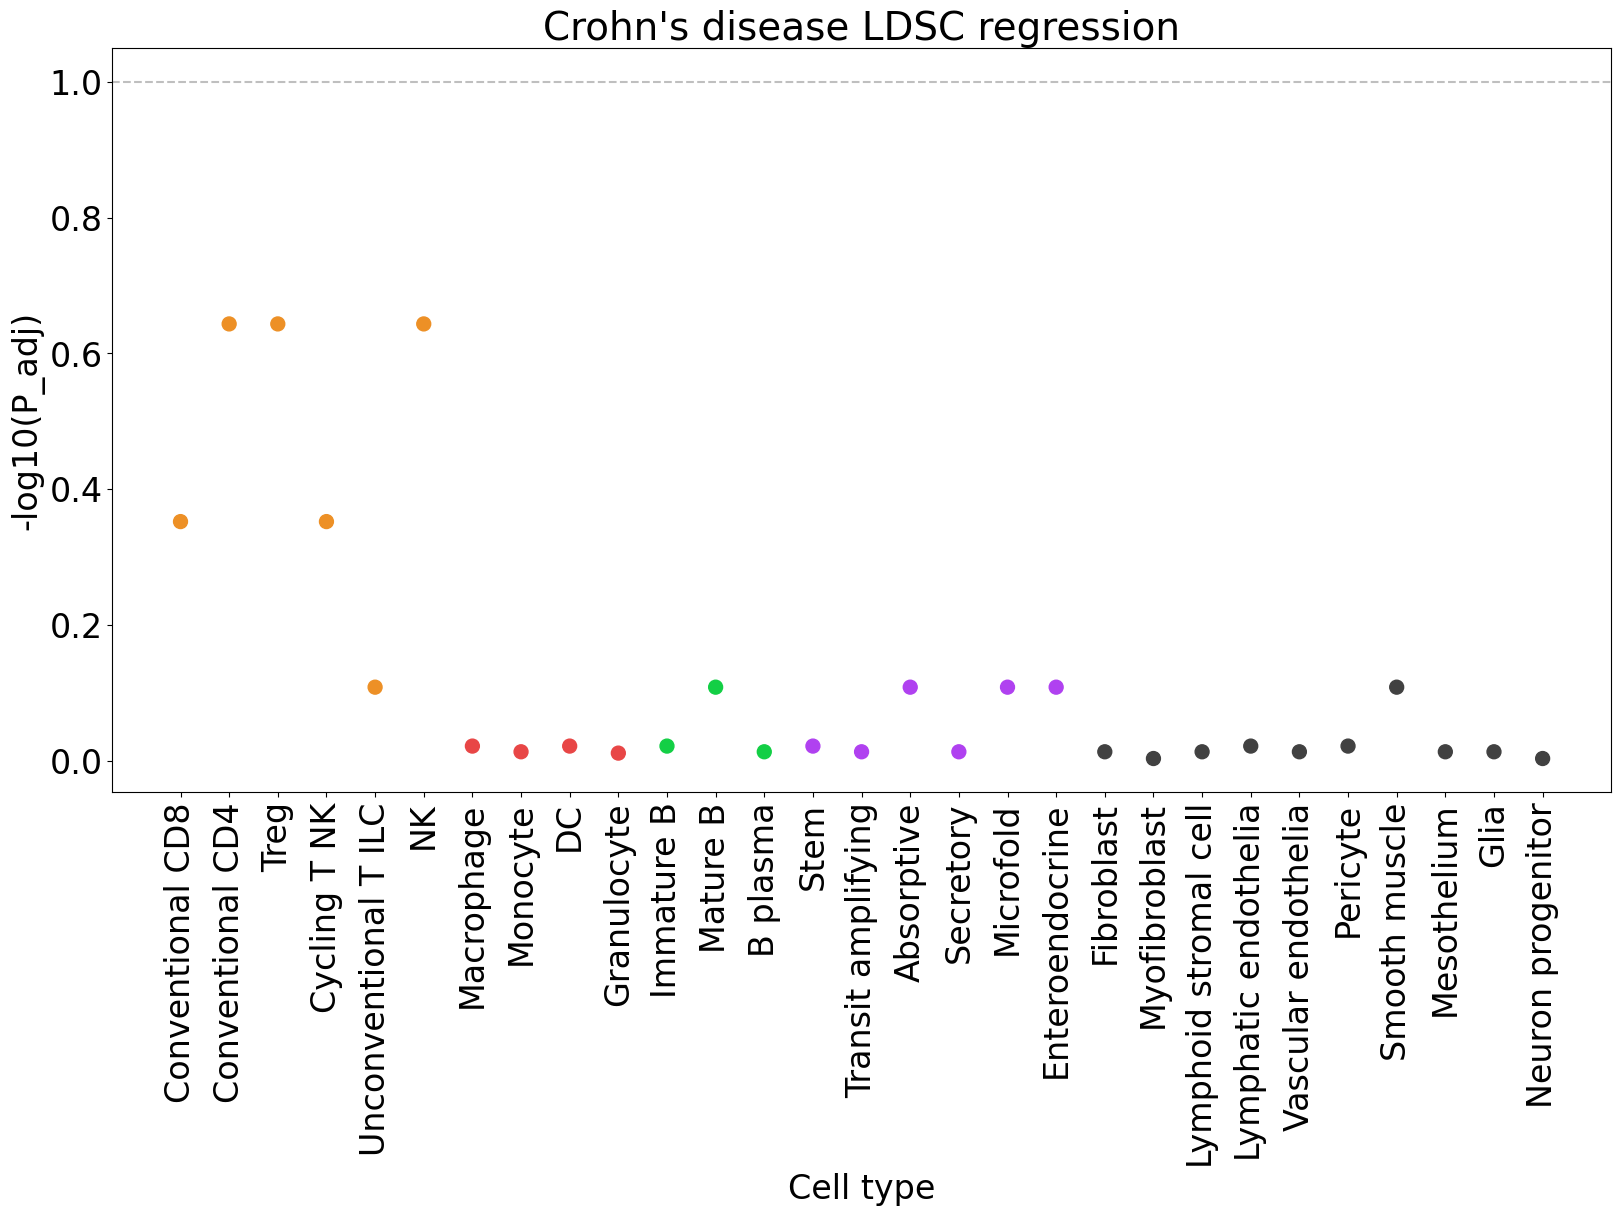

In [21]:
fz=24
p_cutoff = 0.1

plt.figure(figsize=(n_cell_types/1.5, n_cell_types/3))
plt.scatter(
        range(ldsc_results.shape[0]),
        -np.log10(ldsc_results['P_adj']),
        c=[ct_colour_dict[ct] for ct in list(ldsc_results.index)],
        s=100
    )

plt.xlabel("Cell type", fontsize=fz)
plt.ylabel("-log10(P_adj)", fontsize=fz)

plt.title("Crohn's disease LDSC regression", fontsize=fz + 4)
plt.xticks(range(ldsc_results.shape[0]),
           labels=[ct.replace("_", " ") for ct in ldsc_results.index.values],
           rotation=90, fontsize=fz)
plt.yticks(fontsize=fz)

plt.axhline(-np.log10(p_cutoff), linestyle="--", c="grey", alpha=0.5)

plt.show()

### UC

In [22]:
dataset_name = 'GCST90446794_uc'

In [23]:
# load results
ldsc_results = pd.read_csv(f'hca-gut-atlas-downstream/data/ldsc_out/results/{dataset_name}/{dataset_name}_500genes.cell_type_results.txt',
                           sep='\t',
                           index_col=0             
           )

In [24]:
ldsc_results

,Coefficient,Coefficient_std_error,Coefficient_P_value
Name,,,
NK,7.694217e-09,3.637149e-09,0.017196
Cycling_T_NK,7.299543e-09,3.621829e-09,0.021930
Macrophage,4.987342e-09,2.832966e-09,0.039164
DC,5.182622e-09,3.005581e-09,0.042324
Treg,5.228750e-09,3.117119e-09,0.046729
Absorptive,7.087089e-09,5.087266e-09,0.081794
Monocyte,3.602750e-09,2.902031e-09,0.107218
Conventional_CD4,3.325436e-09,2.857809e-09,0.122287
Stem,3.958490e-09,3.667447e-09,0.140214


In [25]:
# Correct P-values with BH correction

from statsmodels.stats.multitest import multipletests

_, ldsc_results["P_adj"], _, _ = multipletests(
    ldsc_results.Coefficient_P_value.values, alpha=0.05, method="fdr_bh"
)

In [26]:
ldsc_results

,Coefficient,Coefficient_std_error,Coefficient_P_value,P_adj
Name,,,,
NK,7.694217e-09,3.637149e-09,0.017196,0.271029
Cycling_T_NK,7.299543e-09,3.621829e-09,0.021930,0.271029
Macrophage,4.987342e-09,2.832966e-09,0.039164,0.271029
DC,5.182622e-09,3.005581e-09,0.042324,0.271029
Treg,5.228750e-09,3.117119e-09,0.046729,0.271029
Absorptive,7.087089e-09,5.087266e-09,0.081794,0.395339
Monocyte,3.602750e-09,2.902031e-09,0.107218,0.400546
Conventional_CD4,3.325436e-09,2.857809e-09,0.122287,0.400546
Stem,3.958490e-09,3.667447e-09,0.140214,0.400546


In [27]:
# sort in meaningful order
ct_ordered = [
  'Conventional_CD8',
  'Conventional_CD4',
  'Treg',
  'Cycling_T_NK',
  'Unconventional_T_ILC',
  'NK',

  'Macrophage',
  'Monocyte',
  'DC',
  'Granulocyte',

  'Immature_B',
  'Mature_B',
  'B_plasma',

  'Stem',
  'Transit_amplifying',
  'Absorptive',
  'Secretory',
  'Microfold',
  'Enteroendocrine',

  'Fibroblast',
  'Myofibroblast',
  'Lymphoid_stromal_cell',
  'Lymphatic_endothelia',
  'Vascular_endothelia',
  'Pericyte',
  'Smooth_muscle',
  'Mesothelium',
  'Glia',
  'Neuron_progenitor'
]

In [28]:
# sort cell types
ldsc_results = ldsc_results.loc[ct_ordered,:]

In [29]:
# get num ber of celltypes for plot dimensions
n_cell_types = ldsc_results.shape[0]

In [30]:
# set colors
ct_colour_dict = {
    'Conventional_CD8':'#ed9026',
    'Conventional_CD4':'#ed9026',
    'Treg':'#ed9026',
    'Cycling_T_NK':'#ed9026',
    'Unconventional_T_ILC':'#ed9026',
    'NK':'#ed9026',

    'Macrophage':'#e84646',
    'Monocyte':'#e84646',
    'DC':'#e84646',
    'Granulocyte':'#e84646',

    'Immature_B':'#13cf45',
    'Mature_B':'#13cf45',
    'B_plasma':'#13cf45',

    'Stem':'#b041f0',
    'Transit_amplifying':'#b041f0',
    'Absorptive':'#b041f0',
    'Secretory':'#b041f0',
    'Microfold':'#b041f0',
    'Enteroendocrine':'#b041f0',

    'Fibroblast':'#414141',
    'Myofibroblast':'#414141',
    'Lymphoid_stromal_cell':'#414141',
    'Lymphatic_endothelia':'#414141',
    'Vascular_endothelia':'#414141',
    'Pericyte':'#414141',
    'Smooth_muscle':'#414141',
    'Mesothelium':'#414141',
    'Glia':'#414141',
    'Neuron_progenitor':'#414141',
}

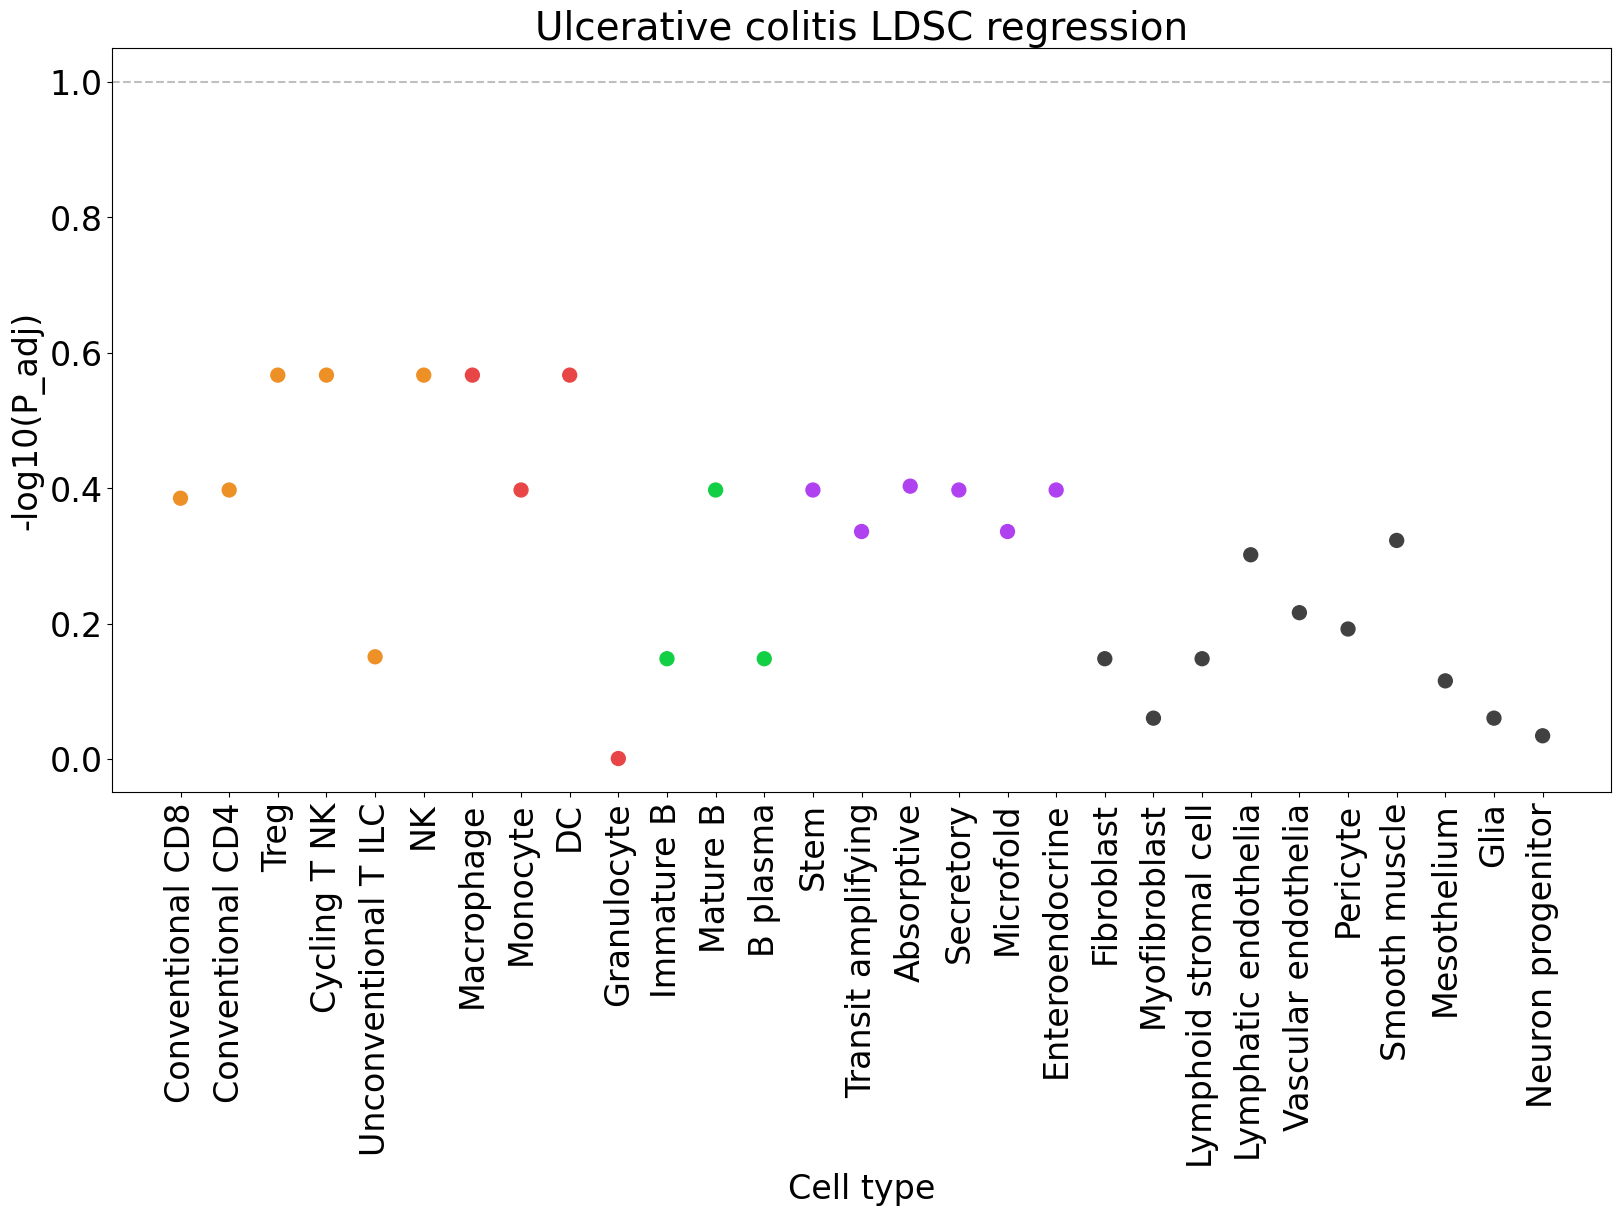

In [31]:
fz=24
p_cutoff = 0.1

plt.figure(figsize=(n_cell_types/1.5, n_cell_types/3))
plt.scatter(
        range(ldsc_results.shape[0]),
        -np.log10(ldsc_results['P_adj']),
        c=[ct_colour_dict[ct] for ct in list(ldsc_results.index)],
        s=100
    )

plt.xlabel("Cell type", fontsize=fz)
plt.ylabel("-log10(P_adj)", fontsize=fz)

plt.title("Ulcerative colitis LDSC regression", fontsize=fz + 4)
plt.xticks(range(ldsc_results.shape[0]),
           labels=[ct.replace("_", " ") for ct in ldsc_results.index.values],
           rotation=90, fontsize=fz)
plt.yticks(fontsize=fz)

plt.axhline(-np.log10(p_cutoff), linestyle="--", c="grey", alpha=0.5)

plt.show()